# Chest X-Ray Pneumonia Detection
**Base model:** DenseNet-121 | **Advanced model:** DINOv2-Base (Oquab et al., *Transactions on Machine Learning Research* 2024)

Dataset: [Kaggle Chest X-Ray Pneumonia](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia)

---
## ▶ Run order
1. Section 1 — Setup & Data
2. Section 2 — Base Model (DenseNet-121)
3. Section 3 — Advanced Model (DINOv2-Base)
4. Section 4 — Results & Figures

---
# Section 1 — Setup & Data Loading

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:10<00:00, 227MB/s]

Unzipped successfully
PyTorch 2.10.0+cu128 | timm 1.0.26 | CUDA: True
Device: cuda
  train/NORMAL: 1341
  train/PNEUMONIA: 3875
  val/NORMAL: 8
  val/PNEUMONIA: 8
  test/NORMAL: 234
  test/PNEUMONIA: 390
Train: 5216 | Val: 16 | Test: 624
Class map: {'NORMAL': 0, 'PNEUMONIA': 1}


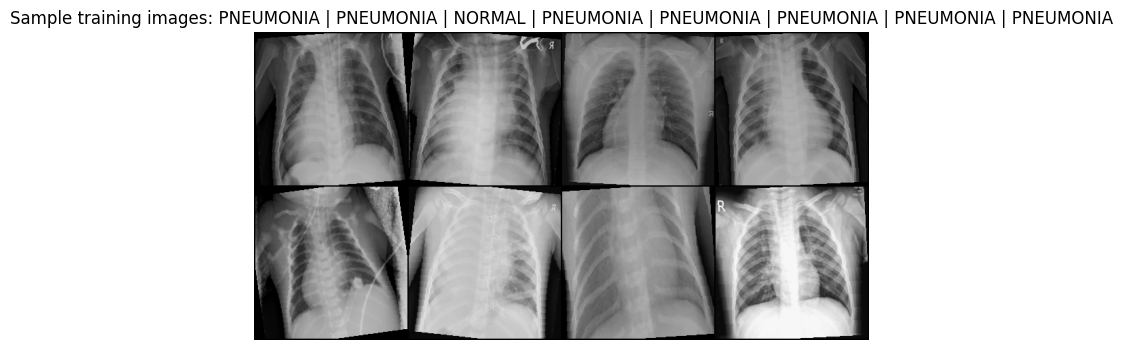

Section 1 complete.


In [ ]:
# ── Install dependencies ──────────────────────────────────────────
# No custom wheels needed — DINOv2 is available natively via timm
!pip install -q timm

# ── Download & unzip dataset ──────────────────────────────────────
import os, sys, json

os.makedirs('/root/.kaggle', exist_ok=True)
token = {"username": "vanshgumber01", "key": "KGAT_aa6d6c754f2af3eb2c13e0b87706de62"}
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(token, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip -d . && echo "Unzipped successfully"

# ── Imports ───────────────────────────────────────────────────────
import time, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.utils import make_grid

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    roc_curve, auc, classification_report
)

import timm

# ── Global config ─────────────────────────────────────────────────
DATA_ROOT    = './chest_xray'
DEVICE       = 'cuda' if torch.cuda.is_available() else 'cpu'
CLASSES      = ['NORMAL', 'PNEUMONIA']
IMG_SIZE     = 224
BATCH_SIZE   = 32
EPOCHS       = 15
LR           = 1e-4
WEIGHT_DECAY = 1e-4
SEED         = 42

torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
if DEVICE == 'cuda': torch.cuda.manual_seed_all(SEED)
print(f'PyTorch {torch.__version__} | timm {timm.__version__} | CUDA: {torch.cuda.is_available()}')
print(f'Device: {DEVICE}')

# ── Verify dataset paths ──────────────────────────────────────────
for split in ['train', 'val', 'test']:
    for cls in CLASSES:
        path = os.path.join(DATA_ROOT, split, cls)
        count = len(os.listdir(path)) if os.path.exists(path) else 'PATH NOT FOUND'
        print(f'  {split}/{cls}: {count}')

# ── Image preprocessing & transforms ─────────────────────────────
# DINOv2 uses the same ImageNet normalisation as DenseNet-121
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# ── DataLoaders ───────────────────────────────────────────────────
train_ds = datasets.ImageFolder(os.path.join(DATA_ROOT, 'train'), train_transforms)
val_ds   = datasets.ImageFolder(os.path.join(DATA_ROOT, 'val'),   val_transforms)
test_ds  = datasets.ImageFolder(os.path.join(DATA_ROOT, 'test'),  val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')
print(f'Class map: {train_ds.class_to_idx}')

# ── Shared training utilities ─────────────────────────────────────
def get_class_weights():
    counts  = np.array([len(os.listdir(os.path.join(DATA_ROOT, 'train', c))) for c in CLASSES])
    weights = counts.sum() / (len(counts) * counts)
    weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)
    print(f'Class weights → NORMAL: {weights[0]:.3f}, PNEUMONIA: {weights[1]:.3f}')
    return weights

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        loss   = criterion(logits, labels)
        probs  = torch.softmax(logits, dim=1)[:, 1]
        total_loss += loss.item() * imgs.size(0)
        preds  = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels, all_probs

def run_training(model, model_name, train_loader, val_loader, epochs=EPOCHS, lr=LR):
    weights   = get_class_weights()
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                            lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history   = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc, best_state = 0.0, None

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc, _, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step()
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
        print(f'[{model_name}] Ep {epoch:02d}/{epochs}  '
              f'TrLoss={tr_loss:.4f} TrAcc={tr_acc:.4f}  '
              f'VlLoss={vl_loss:.4f} VlAcc={vl_acc:.4f}  ({time.time()-t0:.1f}s)')

    model.load_state_dict(best_state)
    print(f'Best val acc: {best_val_acc:.4f}')
    return model, history

# ── Sample image grid ─────────────────────────────────────────────
imgs, labels = next(iter(train_loader))
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
imgs_denorm = (imgs[:8] * std + mean).clamp(0, 1)
grid = make_grid(imgs_denorm, nrow=4)
plt.figure(figsize=(12, 4))
plt.imshow(grid.permute(1, 2, 0))
plt.title('Sample training images: ' + ' | '.join([CLASSES[l] for l in labels[:8].tolist()]))
plt.axis('off')
plt.show()
print('Section 1 complete.')

---
# Section 2 — Base Model: DenseNet-121
Huang et al., CVPR 2017. Established baseline for chest X-ray classification (used in CheXNet).

In [ ]:
# ── Build DenseNet-121 ────────────────────────────────────────────
def build_densenet121(num_classes=2):
    model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    in_features = model.classifier.in_features  # 1024
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, num_classes)
    )
    # Unfreeze last dense block + norm + head
    for param in model.features.denseblock4.parameters(): param.requires_grad = True
    for param in model.features.norm5.parameters():       param.requires_grad = True
    for param in model.classifier.parameters():           param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'DenseNet-121 | Trainable: {trainable:,} / {total:,} params')
    return model.to(DEVICE)

# ── Train ─────────────────────────────────────────────────────────
base_model = build_densenet121()
base_model, base_history = run_training(
    base_model, 'DenseNet121', train_loader, val_loader, epochs=EPOCHS
)

# ── Evaluate on test set ──────────────────────────────────────────
criterion_eval = nn.CrossEntropyLoss()
_, _, base_preds, base_labels, base_probs = evaluate(base_model, test_loader, criterion_eval)

base_metrics = {
    'accuracy' : accuracy_score(base_labels, base_preds),
    'precision': precision_score(base_labels, base_preds, pos_label=1),
    'recall'   : recall_score(base_labels, base_preds, pos_label=1),
    'f1'       : f1_score(base_labels, base_preds, pos_label=1),
    'auc_roc'  : roc_auc_score(base_labels, base_probs),
}
print('\n── DenseNet-121 Test Results ──')
for k, v in base_metrics.items(): print(f'  {k:<12}: {v:.4f}')
print()
print(classification_report(base_labels, base_preds, target_names=CLASSES))
print('Section 2 complete.')

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 114MB/s]


DenseNet-121 | Trainable: 2,685,954 / 7,479,682 params
Class weights → NORMAL: 1.945, PNEUMONIA: 0.673
[DenseNet121] Ep 01/15  TrLoss=0.2249 TrAcc=0.9220  VlLoss=0.1689 VlAcc=1.0000  (103.6s)
[DenseNet121] Ep 02/15  TrLoss=0.0981 TrAcc=0.9632  VlLoss=0.1611 VlAcc=1.0000  (88.4s)
[DenseNet121] Ep 03/15  TrLoss=0.0707 TrAcc=0.9697  VlLoss=0.1878 VlAcc=0.9375  (85.7s)
[DenseNet121] Ep 04/15  TrLoss=0.0661 TrAcc=0.9745  VlLoss=0.1081 VlAcc=0.9375  (83.9s)
[DenseNet121] Ep 05/15  TrLoss=0.0678 TrAcc=0.9757  VlLoss=0.2925 VlAcc=0.8750  (84.9s)
[DenseNet121] Ep 06/15  TrLoss=0.0537 TrAcc=0.9801  VlLoss=0.2946 VlAcc=0.9375  (84.6s)
[DenseNet121] Ep 07/15  TrLoss=0.0501 TrAcc=0.9822  VlLoss=0.0432 VlAcc=1.0000  (85.5s)
[DenseNet121] Ep 08/15  TrLoss=0.0383 TrAcc=0.9856  VlLoss=0.1229 VlAcc=0.9375  (85.3s)
[DenseNet121] Ep 09/15  TrLoss=0.0323 TrAcc=0.9883  VlLoss=0.1931 VlAcc=0.9375  (84.9s)
[DenseNet121] Ep 10/15  TrLoss=0.0337 TrAcc=0.9891  VlLoss=0.1951 VlAcc=0.9375  (86.2s)
[DenseNet121] Ep

---
# Section 3 — Advanced Model: DINOv2-Base (2024)
Oquab et al., *Transactions on Machine Learning Research*, January 2024 ([paper](https://openreview.net/forum?id=a68SUt6zFt) | [arXiv](https://arxiv.org/abs/2304.07193)).

DINOv2 is a self-supervised Vision Transformer (ViT-B/14) pretrained by Meta AI on a curated dataset of 142M images using a distillation-based approach — no labels required during pretraining. It produces general-purpose visual features that transfer exceptionally well across domains, including medical imaging. The base model has 86M parameters and uses 14×14 patch tokens with a 768-dimensional embedding.

We load the pretrained backbone via `timm`, freeze it, and attach a lightweight classification head — then fine-tune the full model at a low learning rate.

In [ ]:
# ── Build DINOv2-Base ─────────────────────────────────────────────
# No custom wheels or repo cloning needed — available directly via timm
def build_dinov2(num_classes=2):
    # ViT-B/14 pretrained with DINOv2 self-supervised learning
    # 'vit_base_patch14_dinov2.lvd142m' = pretrained on LVD-142M curated dataset
    backbone = timm.create_model(
        'vit_base_patch14_dinov2.lvd142m',
        pretrained=True,
        num_classes=0,        # remove default head, we add our own
        img_size=IMG_SIZE,
    )

    # Freeze backbone initially
    for param in backbone.parameters():
        param.requires_grad = False

    embed_dim = backbone.embed_dim  # 768 for ViT-Base

    # Wrap backbone + classification head into one module
    class DINOv2Classifier(nn.Module):
        def __init__(self, backbone, embed_dim, num_classes):
            super().__init__()
            self.backbone = backbone
            self.head = nn.Sequential(
                nn.LayerNorm(embed_dim),
                nn.Linear(embed_dim, 256),
                nn.GELU(),
                nn.Dropout(0.3),
                nn.Linear(256, num_classes)
            )

        def forward(self, x):
            features = self.backbone(x)   # (B, embed_dim) CLS token
            return self.head(features)

    model = DINOv2Classifier(backbone, embed_dim, num_classes)

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'DINOv2-Base | Trainable (head only): {trainable:,} / {total:,} params')
    return model.to(DEVICE)

adv_model = build_dinov2(num_classes=2)

# ── Stage 1: Train head only (3 epochs, frozen backbone) ─────────
# Warm up the classification head before unfreezing the backbone
print('\n── Stage 1: Head warm-up (backbone frozen) ──')
adv_model, _ = run_training(
    adv_model, 'DINOv2_warmup', train_loader, val_loader,
    epochs=3, lr=1e-3
)

# ── Stage 2: Unfreeze full model, fine-tune at low LR ────────────
print('\n── Stage 2: Full fine-tune (all layers, low LR) ──')
for param in adv_model.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in adv_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in adv_model.parameters())
print(f'DINOv2-Base | Trainable (full): {trainable:,} / {total:,} params')

adv_model, adv_history = run_training(
    adv_model, 'DINOv2_Base', train_loader, val_loader,
    epochs=EPOCHS, lr=5e-5
)

# ── Evaluate on test set ──────────────────────────────────────────
_, _, adv_preds, adv_labels, adv_probs = evaluate(adv_model, test_loader, nn.CrossEntropyLoss())

adv_metrics = {
    'accuracy' : accuracy_score(adv_labels, adv_preds),
    'precision': precision_score(adv_labels, adv_preds, pos_label=1),
    'recall'   : recall_score(adv_labels, adv_preds, pos_label=1),
    'f1'       : f1_score(adv_labels, adv_preds, pos_label=1),
    'auc_roc'  : roc_auc_score(adv_labels, adv_probs),
}
print('\n── DINOv2-Base Test Results ──')
for k, v in adv_metrics.items(): print(f'  {k:<12}: {v:.4f}')
print()
print(classification_report(adv_labels, adv_preds, target_names=CLASSES))
print('Section 3 complete.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

DINOv2-Base | Trainable (head only): 198,914 / 85,923,842 params

── Stage 1: Head warm-up (backbone frozen) ──
Class weights → NORMAL: 1.945, PNEUMONIA: 0.673
[DINOv2_warmup] Ep 01/3  TrLoss=0.2816 TrAcc=0.8771  VlLoss=0.4253 VlAcc=0.7500  (116.8s)
[DINOv2_warmup] Ep 02/3  TrLoss=0.1694 TrAcc=0.9321  VlLoss=0.4661 VlAcc=0.7500  (114.0s)
[DINOv2_warmup] Ep 03/3  TrLoss=0.1368 TrAcc=0.9452  VlLoss=0.6105 VlAcc=0.7500  (112.8s)
Best val acc: 0.7500

── Stage 2: Full fine-tune (all layers, low LR) ──
DINOv2-Base | Trainable (full): 85,923,842 / 85,923,842 params
Class weights → NORMAL: 1.945, PNEUMONIA: 0.673
[DINOv2_Base] Ep 01/15  TrLoss=0.7591 TrAcc=0.5550  VlLoss=0.6480 VlAcc=0.5000  (248.6s)
[DINOv2_Base] Ep 02/15  TrLoss=0.6982 TrAcc=0.5412  VlLoss=0.6574 VlAcc=0.5000  (247.5s)
[DINOv2_Base] Ep 03/15  TrLoss=0.5609 TrAcc=0.6931  VlLoss=1.3769 VlAcc=0.5000  (249.2s)
[DINOv2_Base] Ep 04/15  TrLoss=0.4127 TrAcc=0.7949  VlLoss=1.3288 VlAcc=0.5000  (248.6s)
[DINOv2_Base] Ep 05/15  TrLoss

---
# Section 4 — Results & Figures
Loss/accuracy curves, confusion matrices, ROC curves, and metric comparison.

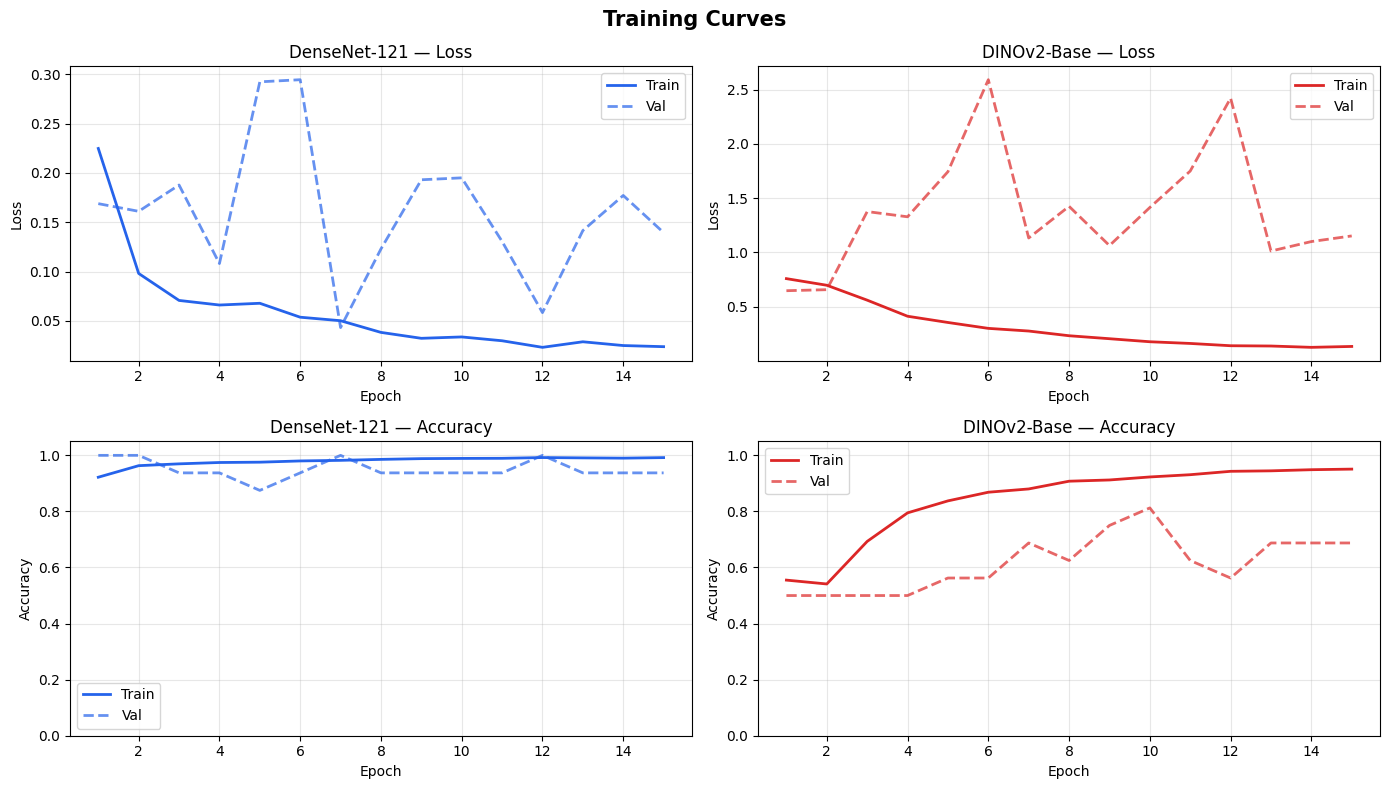

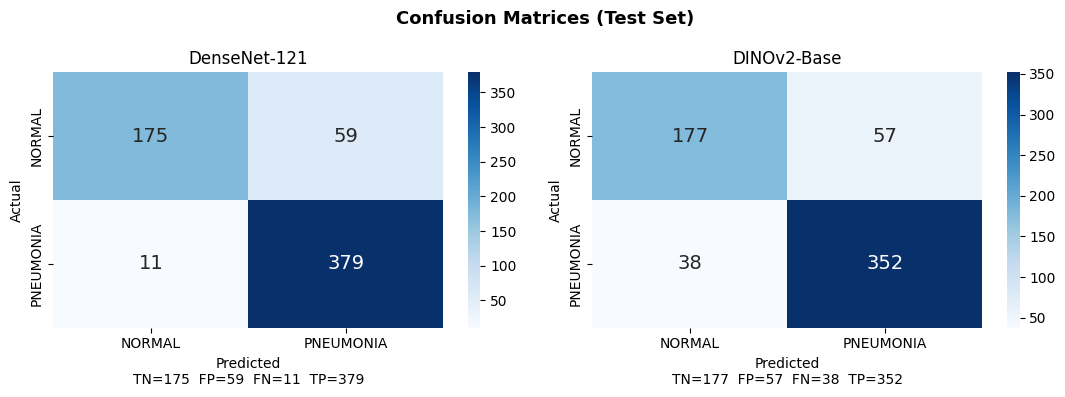

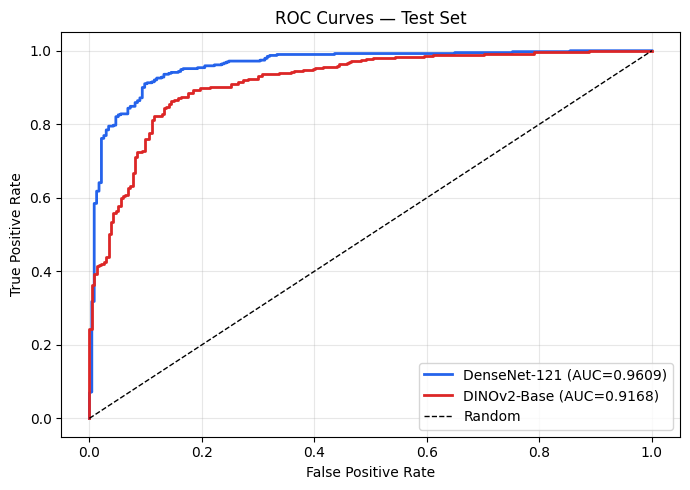

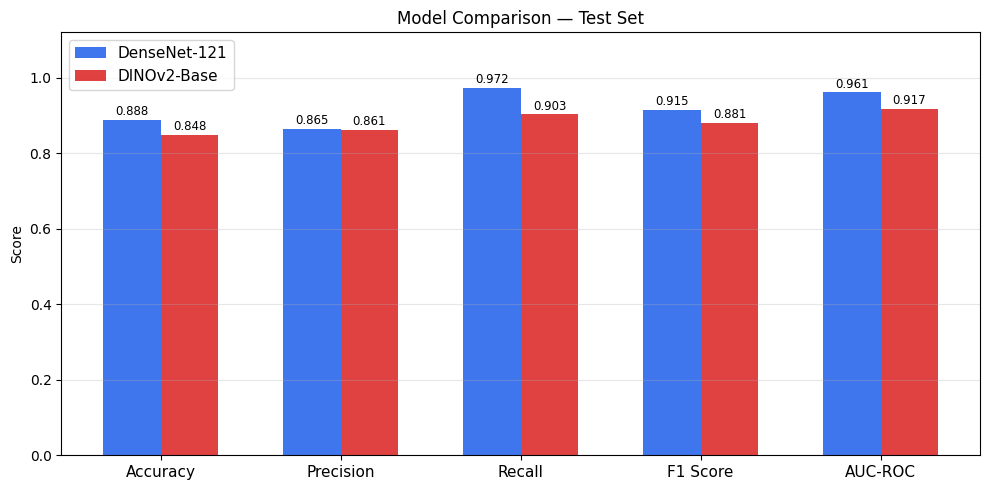

Metric           DenseNet-121    DINOv2-Base        Δ
--------------------------------------------------------------
Accuracy               0.8878         0.8478 ▼0.0401
Precision              0.8653         0.8606 ▼0.0047
Recall                 0.9718         0.9026 ▼0.0692
F1 Score               0.9155         0.8811 ▼0.0344
AUC-ROC                0.9609         0.9168 ▼0.0441
Section 4 complete.


In [ ]:
metric_keys   = ['accuracy', 'precision', 'recall', 'f1', 'auc_roc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']

# ── Fig 1: Loss & Accuracy Curves ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Training Curves', fontsize=15, fontweight='bold')

for col, (name, hist, color) in enumerate([
    ('DenseNet-121', base_history, '#2563EB'),
    ('DINOv2-Base',  adv_history,  '#DC2626'),
]):
    epochs_range = range(1, len(hist['train_loss']) + 1)
    axes[0][col].plot(epochs_range, hist['train_loss'], color=color, linewidth=2, label='Train')
    axes[0][col].plot(epochs_range, hist['val_loss'],   color=color, linewidth=2, linestyle='--', alpha=0.7, label='Val')
    axes[0][col].set_title(f'{name} — Loss'); axes[0][col].set_xlabel('Epoch'); axes[0][col].set_ylabel('Loss')
    axes[0][col].legend(); axes[0][col].grid(True, alpha=0.3)

    axes[1][col].plot(epochs_range, hist['train_acc'], color=color, linewidth=2, label='Train')
    axes[1][col].plot(epochs_range, hist['val_acc'],   color=color, linewidth=2, linestyle='--', alpha=0.7, label='Val')
    axes[1][col].set_title(f'{name} — Accuracy'); axes[1][col].set_xlabel('Epoch'); axes[1][col].set_ylabel('Accuracy')
    axes[1][col].set_ylim(0, 1.05); axes[1][col].legend(); axes[1][col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Fig 2: Confusion Matrices ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Confusion Matrices (Test Set)', fontsize=13, fontweight='bold')

for ax, (name, preds, labels) in zip(axes, [
    ('DenseNet-121', base_preds, base_labels),
    ('DINOv2-Base',  adv_preds,  adv_labels),
]):
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax, annot_kws={'size': 14})
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(name); ax.set_xlabel(f'Predicted\nTN={tn}  FP={fp}  FN={fn}  TP={tp}')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

# ── Fig 3: ROC Curves ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
for name, labels, probs, color in [
    ('DenseNet-121', base_labels, base_probs, '#2563EB'),
    ('DINOv2-Base',  adv_labels,  adv_probs,  '#DC2626'),
]:
    fpr, tpr, _ = roc_curve(labels, probs)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc(fpr,tpr):.4f})')

ax.plot([0,1],[0,1],'k--',linewidth=1,label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Test Set'); ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Fig 4: Metric Comparison Bar Chart ───────────────────────────
x = np.arange(len(metric_keys)); width = 0.32

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, [base_metrics[k] for k in metric_keys], width, label='DenseNet-121', color='#2563EB', alpha=0.88)
bars2 = ax.bar(x + width/2, [adv_metrics[k]  for k in metric_keys], width, label='DINOv2-Base',  color='#DC2626', alpha=0.88)
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8.5)
ax.set_xticks(x); ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1.12); ax.set_ylabel('Score')
ax.set_title('Model Comparison — Test Set'); ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ── Summary Table ─────────────────────────────────────────────────
print('='*62)
print(f'{"Metric":<14} {"DenseNet-121":>14} {"DINOv2-Base":>14} {"Δ":>8}')
print('-'*62)
for k, label in zip(metric_keys, metric_labels):
    b, a = base_metrics[k], adv_metrics[k]
    arrow = '▲' if a > b else '▼'
    print(f'{label:<14} {b:>14.4f} {a:>14.4f} {arrow}{abs(a-b):>6.4f}')
print('='*62)
print('Section 4 complete.')